# Task 3 — Naive Bayes: Spam vs. Ham Email/SMS Classification

We use the **UCI SMS Spam Collection**, a real dataset of 5,574 SMS messages
manually labeled as `spam` or `ham`. We clean the text, vectorize it with
TF-IDF, and classify with **Multinomial Naive Bayes**.

In [1]:
import re
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

raw_bytes = urllib.request.urlopen(DATA_URL, timeout=30).read()
with zipfile.ZipFile(io.BytesIO(raw_bytes)) as zf:
    with zf.open("SMSSpamCollection") as f:
        df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])

print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Cleaning

- Drop exact duplicate rows (SMS spam datasets typically contain many repeated
  spam templates).
- Check for missing values.
- Normalize text: lowercase, strip URLs/emails/numbers/punctuation, collapse
  whitespace. Stopword removal is delegated to `TfidfVectorizer(stop_words="english")`.

In [3]:
print("nulls:\n", df.isnull().sum())
print("duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_message"] = df["message"].apply(clean_text)
df["label"] = df["label"].map({"ham": 0, "spam": 1})
df[["message", "clean_message", "label"]].head()

nulls:
 label      0
message    0
dtype: int64
duplicate rows: 403


,message,clean_message,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,0


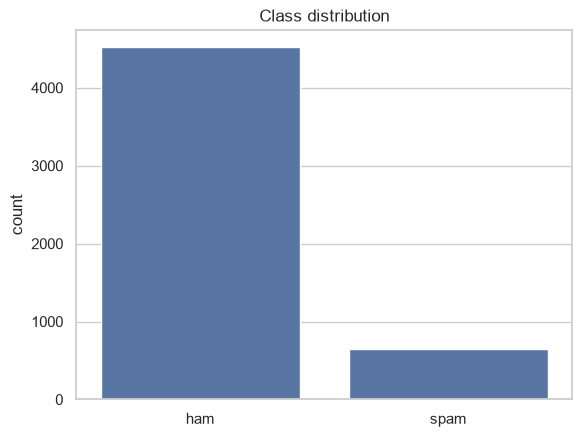

label
0    0.87367
1    0.12633
Name: proportion, dtype: float64

In [4]:
ax = sns.countplot(x=df["label"].map({0: "ham", 1: "spam"}))
ax.set_title("Class distribution")
ax.set_xlabel("")
plt.show()

df["label"].value_counts(normalize=True)

## Feature extraction + Multinomial Naive Bayes

We split the data first (to avoid leakage), then fit a TF-IDF vectorizer on
the training messages only.

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_message"], df["label"], test_size=0.2, random_state=42,
    stratify=df["label"],
)

vectorizer = TfidfVectorizer(stop_words="english", min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("vocab size:", len(vectorizer.vocabulary_))

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

vocab size: 2836


              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       903
        spam       1.00      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034

{'accuracy': 0.9748549323017408, 'precision': 1.0, 'recall': 0.8015267175572519, 'f1': 0.8898305084745762}


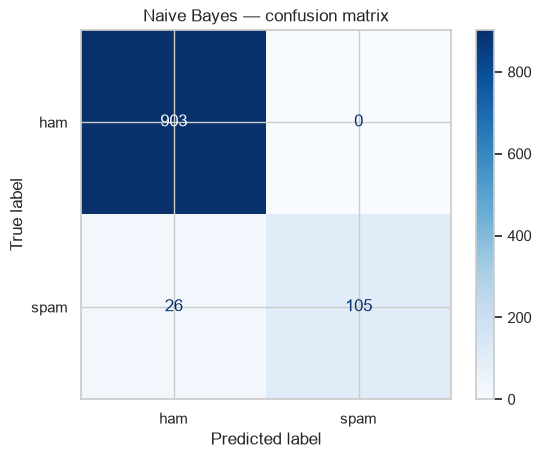

In [6]:
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
}
print(metrics)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title("Naive Bayes — confusion matrix")
plt.show()

## Conclusion

Multinomial Naive Bayes on TF-IDF features achieves strong precision/recall on
this real, imbalanced (≈13% spam) SMS dataset, confirming Naive Bayes' classic
strength on high-dimensional sparse text features.